In [56]:
from pathlib import Path
DATA_DIR = Path("../../data/gamma-b")

In [57]:
import pandas as pd
df = pd.read_csv(DATA_DIR / "to_filter.tsv", delimiter="\t", low_memory=False)

In [58]:
print(df.head())
print(df.info())

  Assembly Name Assembly Accession Assembly Paired Assembly Accession  \
0      ASM694v2    GCA_000006945.2                    GCF_000006945.2   
1      ASM694v2    GCF_000006945.2                    GCA_000006945.2   
2   ASM903584v1    GCA_009035845.1                    GCF_009035845.1   
3   ASM903584v1    GCF_009035845.1                    GCA_009035845.1   
4    ASM41267v1    GCA_000412675.1                    GCF_000412675.1   

                                       Organism Name ANI Check status  \
0  Salmonella enterica subsp. enterica serovar Ty...               OK   
1  Salmonella enterica subsp. enterica serovar Ty...               OK   
2                            Acinetobacter baumannii               OK   
3                            Acinetobacter baumannii               OK   
4                      Pseudomonas putida NBRC 14164               OK   

   Organism Infraspecific Names Breed Organism Infraspecific Names Strain  \
0                                 NaN        

In [59]:
import os
print(f"Number of unique assemblies: {df['Organism Name'].nunique()}")
print(f"Number of reference assemblies: {len(os.listdir(DATA_DIR / 'reference_only'))}")

Number of unique assemblies: 5531
Number of reference assemblies: 1393


In [60]:
print(df["ANI Check status"].value_counts())

ANI Check status
OK              57104
Inconclusive     2736
Failed            157
Name: count, dtype: int64


In [61]:
# Organismos que tienen AL MENOS UN accession GCF
has_gcf = df.groupby('Organism Name')['Assembly Accession'].transform(
    lambda x: x.str.startswith('GCF').any()
)

# Máscara: es GCF en ese row
is_gcf = df['Assembly Accession'].str.startswith('GCF')

# Conservar:
# - Filas GCF de organismos que tienen GCF
# - Todas las filas de organismos que NO tienen ningún GCF
df = df[~has_gcf | is_gcf].reset_index(drop=True)

In [62]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 29503 entries, 0 to 29502
Data columns (total 19 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Assembly Name                          29498 non-null  str    
 1   Assembly Accession                     29503 non-null  str    
 2   Assembly Paired Assembly Accession     29254 non-null  str    
 3   Organism Name                          29503 non-null  str    
 4   ANI Check status                       29470 non-null  str    
 5   Organism Infraspecific Names Breed     0 non-null      float64
 6   Organism Infraspecific Names Strain    28374 non-null  str    
 7   Organism Infraspecific Names Cultivar  0 non-null      float64
 8   Organism Infraspecific Names Ecotype   6 non-null      str    
 9   Organism Infraspecific Names Isolate   1822 non-null   str    
 10  Organism Infraspecific Names Sex       0 non-null      float64
 11  Annotation Na

In [63]:
df['failure_prob'] = (df['CheckM contamination'] / 100) * (1 - (df['CheckM completeness'] / 100))

df = df.sort_values('failure_prob', ascending=True)\
       .drop_duplicates(subset='Organism Name')\
       .drop(columns='failure_prob')

In [64]:
# Check that there are no duplicates
print(df["Organism Name"].nunique() - len(df["Organism Name"]))

0


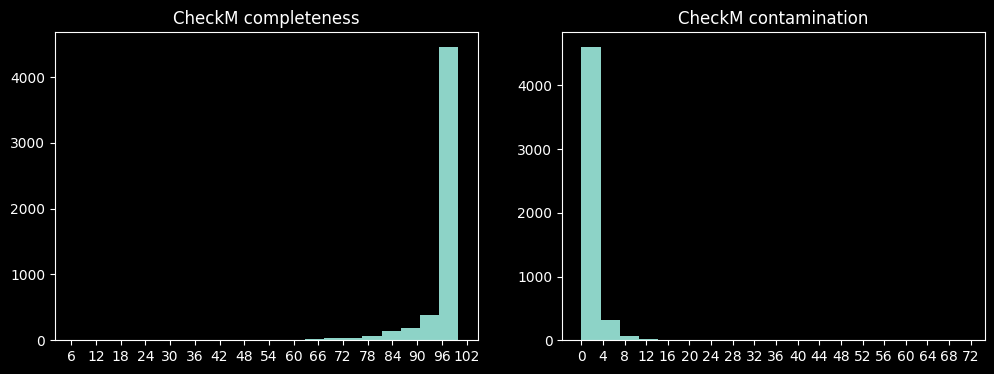

In [65]:
from matplotlib import pyplot as plt
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].hist(df["CheckM completeness"].values, bins=20)
axs[0].set_title("CheckM completeness")
axs[0].xaxis.set_major_locator(plt.MaxNLocator(20))

axs[1].hist(df["CheckM contamination"].values, bins=20)
axs[1].set_title("CheckM contamination")
axs[1].xaxis.set_major_locator(plt.MaxNLocator(20))

plt.show()

In [66]:
# Remove the ones that have completeness < 80 or contamination > 8
print(len(df))
df = df[(df["CheckM completeness"] >= 80) | (df["CheckM contamination"] <= 8)]
print(len(df))

5531
5295


In [67]:
# Remove the ones without annotation
print(df["Annotation Name"].value_counts())

Annotation Name
NCBI Prokaryotic Genome Annotation Pipeline (PGAP)    138
Annotation submitted by NCBI RefSeq                     6
Annotation submitted by SC                              2
Annotation submitted by Keio University                 2
GCF_022807995.1-RS_2025_06_06                           1
                                                     ... 
GCF_965263005.1-RS_2025_05_14                           1
GCF_965228465.1-RS_2025_04_03                           1
GCF_965227175.1-RS_2025_05_02                           1
GCF_965140365.1-RS_2026_03_05                           1
GCF_965221325.1-RS_2025_11_17                           1
Name: count, Length: 5151, dtype: int64


In [68]:
# Store the organisms name in a txt file for downloading
out = "\n".join(df["Assembly Accession"])
with open(DATA_DIR / "to_download.txt", "w") as f:
    f.write(out)